<a href="https://colab.research.google.com/github/zizizw/Business-Analytics-Projects/blob/main/JD_com_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Data and Packages

In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

In [ ]:
delivery = pd.read_csv('JD_delivery_data.csv')
inventory = pd.read_csv('JD_inventory_data.csv')
network = pd.read_csv('JD_network_data.csv')
order = pd.read_csv('JD_order_data.csv')
user = pd.read_csv('JD_user_data.csv')

# Data Processing

In [ ]:
unique_order_count = order['order_ID'].nunique()
print(f"Number of unique orders: {unique_order_count}")

Number of unique orders: 486928


In [ ]:
# Count number of packages per order_ID
package_counts = delivery.groupby('order_ID')['package_ID'].nunique()

# Filter for orders with 2 or more packages
multi_package_orders = package_counts[package_counts >= 2]

# Get the count of such orders
num_multi_package_orders = multi_package_orders.count()
print(f"Number of orders with 2 or more packages: {num_multi_package_orders}")

# Find order_IDs with multiple packages
multi_package_ids = multi_package_orders.index

# Filter delivery DataFrame for those order_IDs
multi_package_df = delivery[delivery['order_ID'].isin(multi_package_ids)].sort_values(by='order_ID')

Number of orders with 2 or more packages: 22


order level analysis: there are only 22 orders have 2 or more packages, therefore combining the multi-package delivery and use the last arr_time across all packages for each order_ID

aggregate delivery

In [ ]:
# Step 1: Convert to datetime
delivery['ship_out_time'] = pd.to_datetime(delivery['ship_out_time'])
delivery['arr_station_time'] = pd.to_datetime(delivery['arr_station_time'])
delivery['arr_time'] = pd.to_datetime(delivery['arr_time'])

# Step 2: Get final (max) times per order_ID
final_times = delivery.groupby('order_ID').agg({
    'ship_out_time': 'min',
    'arr_station_time': 'max',
    'arr_time': 'max'
}).reset_index()

# Step 3: Keep only one row per order_ID — you can choose 'first' or 'last' or any method
delivery_unique = delivery.drop_duplicates(subset='order_ID', keep='first').copy()

# Step 4: Merge final times into the unique set
delivery_unique = delivery_unique.drop(columns=['ship_out_time', 'arr_station_time', 'arr_time'])
delivery_unique = delivery_unique.merge(final_times, on='order_ID', how='left')

# Now delivery_unique has only one row per order_ID, with updated final time info

aggregate order

In [ ]:
# Calculate the total value of each sku
order['original_value'] = order['quantity'] * order['original_unit_price']

join order with inventory

In [ ]:
# Step 1: Prepare a lookup set from inventory
inventory['key'] = inventory['dc_ID'].astype(str) + "_" + inventory['sku_ID'].astype(str) + "_" + inventory['date'].astype(str)
inventory_keys = set(inventory['key'])

# Step 2: Create the corresponding key in order df
order['key'] = order['dc_ori'].astype(str) + "_" + order['sku_ID'].astype(str) + "_" + order['order_date'].astype(str)

# Step 3: Check if SKU exists in inventory
order['sku_in_stock'] = order['key'].isin(inventory_keys).astype(int)

In [ ]:
# Get the order level data
grouped_order_value = order.groupby(
    ['order_ID', 'user_ID', 'order_date', 'order_time', 'type', 'promise', 'dc_ori', 'dc_des']
).agg({
    'original_value': 'sum',                       # Sum of order values
    'sku_ID': lambda x: ','.join(x.astype(str)),   # Join all SKUs into one string
    'quantity': 'sum',                              # Sum of quantities
    'sku_in_stock': 'min'                          # Any sku missing mark the order as out of stock (1 or 0)
}).reset_index()

# Rename the new columns for clarity
grouped_order_value.rename(columns={
    'sku_ID': 'all_sku_in_order',
    'quantity': 'total_quantity'
}, inplace=True)

join order and delivery

In [ ]:
# Rename 'type' in each DataFrame
grouped_order_value_renamed = grouped_order_value.rename(columns={'type': 'type_order'})
delivery_unique_dropped = delivery_unique.drop(columns=['type'])

# Now perform the merge
order_delivery = pd.merge(grouped_order_value_renamed, delivery_unique_dropped, on='order_ID', how='left')

In [ ]:
# Count rows where arr_time is NaN
arr_time_na_count = order_delivery['arr_time'].isna().sum()
print(f"Number of rows with missing arr_time: {arr_time_na_count}")

Number of rows with missing arr_time: 193724


filter out orders without delivery data

In [ ]:
# Remove rows where arr_time is NaN
order_delivery_clean = order_delivery[order_delivery['arr_time'].notna()].copy()

calculate shippment time = arr_time - ship_out_time

Here we are not considering the time from order_time to ship_out_time because the responsiveness of received order depends on what time the customer place an order during the day as well as the efficiency of different distribution centers assigned.

In [ ]:
# Calculate shipment duration
order_delivery_clean['shipment_time'] = order_delivery_clean['arr_time'] - order_delivery_clean['ship_out_time']

# As total days to compare with promise
order_delivery_clean['shipment_time_days'] = order_delivery_clean['shipment_time'].dt.total_seconds() / (3600 * 24)

Join with user

In [ ]:
# Join order_delivery_clean with user on user_ID
order_delivery_user = pd.merge(order_delivery_clean, user, on='user_ID', how='left')

create is_late label

In [ ]:
order_delivery_user['promise'] = pd.to_numeric(order_delivery_user['promise'], errors='coerce')
order_delivery_user['is_late'] = (order_delivery_user['shipment_time_days'] > order_delivery_user['promise']).astype(int)


join with region

In [ ]:
# Step 0: Join with network table to get region IDs
# First, rename for clear joining
network_ori = network.rename(columns={'dc_ID': 'dc_ori', 'region_ID': 'region_ori'})
network_des = network.rename(columns={'dc_ID': 'dc_des', 'region_ID': 'region_des'})

# Step 1: Copy df_network
df_network = order_delivery_user.copy()

# Step 2: Merge to get region_ori and region_des
df_network = df_network.merge(network_ori[['dc_ori', 'region_ori']], on='dc_ori', how='left')
df_network = df_network.merge(network_des[['dc_des', 'region_des']], on='dc_des', how='left')

# Step 4: Print late delivery count
print("Late delivery:", df_network['is_late'].value_counts())


Late delivery: is_late
0    275519
1     17685
Name: count, dtype: int64


contain some distribution cannot be found in the network table, drop these columns

In [ ]:
# ==== Check and Drop NaNs in Specific Columns ====
print("\n===== Missing Value Count Before Dropping =====")
print(df_network[['region_ori', 'region_des']].isna().sum())

# Drop rows where dc_ori or dc_des is NaN
df_network = df_network.dropna(subset=['region_ori', 'region_des'])

print("\nShape after dropping rows with missing region_ori or region_des:", df_network.shape)


===== Missing Value Count Before Dropping =====
region_ori        0
region_des    23783
dtype: int64

Shape after dropping rows with missing region_ori or region_des: (269421, 30)


# Model

In [ ]:
df = df_network.copy()
df.columns

Index(['order_ID', 'user_ID', 'order_date', 'order_time', 'type_order',
       'promise', 'dc_ori', 'dc_des', 'original_value', 'all_sku_in_order',
       'total_quantity', 'sku_in_stock', 'package_ID', 'ship_out_time',
       'arr_station_time', 'arr_time', 'shipment_time', 'shipment_time_days',
       'user_level', 'first_order_month', 'plus', 'gender', 'age',
       'marital_status', 'education', 'city_level', 'purchase_power',
       'is_late', 'region_ori', 'region_des'],
      dtype='object')

### Random Forest

to get feature importance

Train Class Distribution:
is_late
0    0.938662
1    0.061338
Name: proportion, dtype: float64

Test Class Distribution:
is_late
0    0.938659
1    0.061341
Name: proportion, dtype: float64

===== Random Forest Classification Results =====
Accuracy: 91.05%
Precision: 14.04%
Recall: 8.96%
F1 Score: 10.94%

Confusion Matrix:
[[73151  2718]
 [ 4514   444]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     75869
           1       0.14      0.09      0.11      4958

    accuracy                           0.91     80827
   macro avg       0.54      0.53      0.53     80827
weighted avg       0.89      0.91      0.90     80827


===== Random Forest Feature Importance (Top 15) =====
             feature  importance
4     original_value    0.297774
1         user_level    0.082832
8             dc_des    0.073741
6            promise    0.063255
10        city_level    0.059128
9          education    0.053773
7      

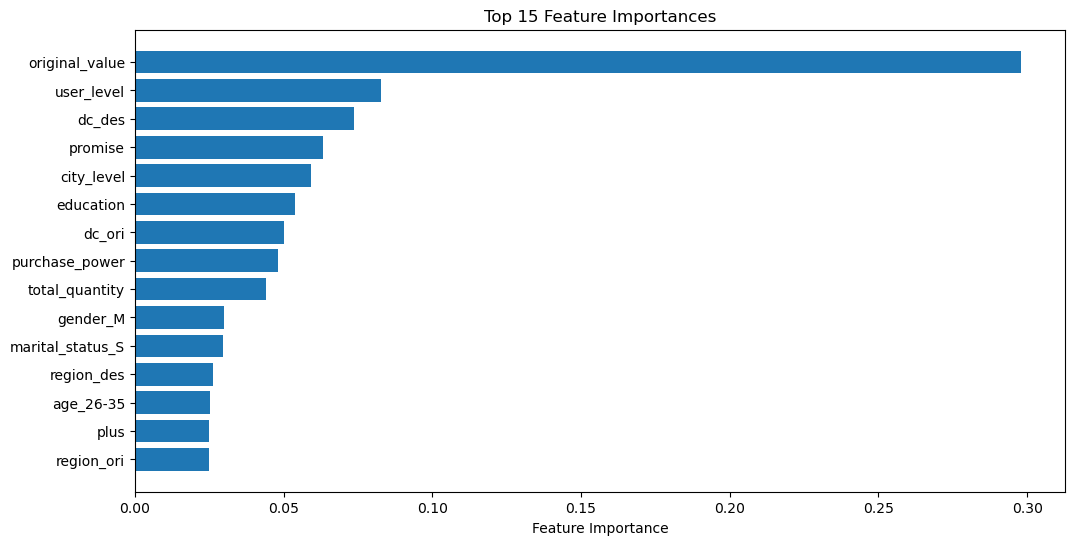

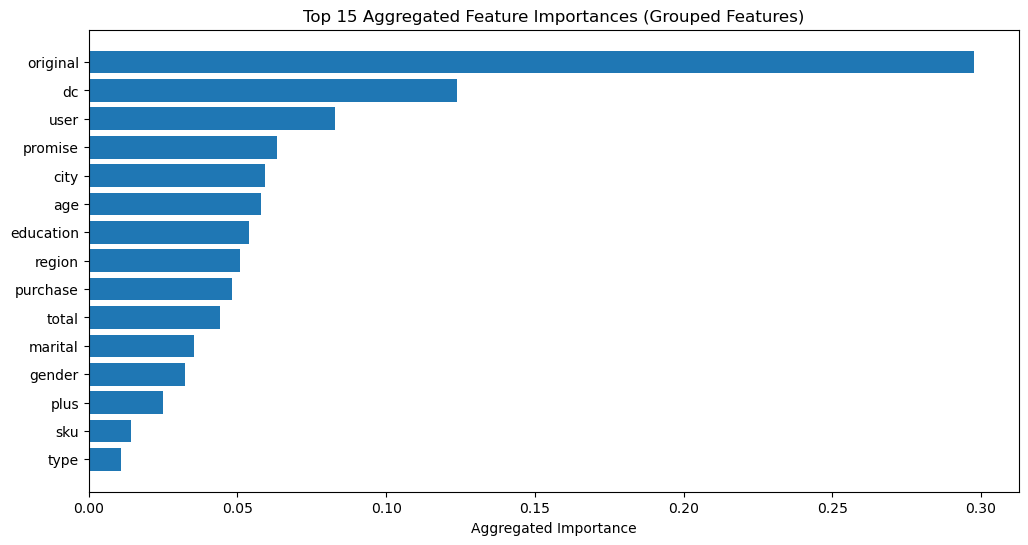

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# ==== Step 1: Data Cleaning ====
df['order_date'] = pd.to_datetime(df['order_date'])
df = df.sort_values('order_date')

# ==== Step 2: Stratified Train-Test Split based on is_late ====
train_df, test_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['is_late']
)

print("Train Class Distribution:")
print(train_df['is_late'].value_counts(normalize=True))
print("\nTest Class Distribution:")
print(test_df['is_late'].value_counts(normalize=True))

# ==== Step 3: Features & Target ====
features = ['type_order', 'promise', 'dc_ori', 'dc_des', 'original_value',
            'user_level', 'plus', 'total_quantity',
            'gender', 'age', 'marital_status', 'education', 'sku_in_stock',
            'city_level', 'purchase_power', 'region_ori', 'region_des']

target_class = 'is_late'

# ==== Step 4: Encode Categorical Variables Correctly ====
categorical_cols = ['type_order', 'promise', 'dc_ori', 'dc_des',
                    'gender', 'age', 'marital_status', 'education',
                    'city_level', 'purchase_power', 'region_ori', 'region_des']

# Separate categorical and numerical columns
X_train_cat = pd.get_dummies(train_df[categorical_cols], drop_first=True)
X_test_cat = pd.get_dummies(test_df[categorical_cols], drop_first=True)

# Align test set columns
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

# Keep numeric columns as they are
numeric_cols = list(set(features) - set(categorical_cols))
X_train_num = train_df[numeric_cols]
X_test_num = test_df[numeric_cols]

# Combine numeric + encoded categorical features
X_train = pd.concat([X_train_num.reset_index(drop=True), X_train_cat.reset_index(drop=True)], axis=1)
X_test = pd.concat([X_test_num.reset_index(drop=True), X_test_cat.reset_index(drop=True)], axis=1)

# Define target values
y_train = train_df[target_class].astype(int)
y_test = test_df[target_class].astype(int)

# Ensure feature types are numeric
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# ==== Step 5: Fit Random Forest Classifier ====
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf.fit(X_train, y_train)

# ==== Step 6: Predict and Evaluate ====
y_pred = rf_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n===== Random Forest Classification Results =====")
print(f"Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1 Score: {f1:.2%}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==== Step 7: Feature Importance ====
importances = rf_clf.feature_importances_
rf_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\n===== Random Forest Feature Importance (Top 15) =====")
print(rf_importance_df.head(15))

# ==== Step 7.5: Aggregate Feature Importance by Base Feature ====
rf_importance_df['base_feature'] = rf_importance_df['feature'].apply(lambda x: x.split('_')[0])
aggregated_importance = rf_importance_df.groupby('base_feature')['importance'].sum().sort_values(ascending=False)

print("\n===== Aggregated Feature Importances (Top 15) =====")
print(aggregated_importance.head(15))

# ==== Step 8: Plot Top 15 Feature Importance ====
plt.figure(figsize=(12, 6))
plt.barh(rf_importance_df['feature'].head(15), rf_importance_df['importance'].head(15))
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

# ==== Step 8.5: Plot Top 15 Aggregated Feature Importance ====
plt.figure(figsize=(12, 6))
plt.barh(aggregated_importance.head(15).index, aggregated_importance.head(15).values)
plt.xlabel('Aggregated Importance')
plt.title('Top 15 Aggregated Feature Importances (Grouped Features)')
plt.gca().invert_yaxis()
plt.show()


# Delay EDA

In [ ]:
df_late = df_network[df_network['is_late'] == 1]


In [ ]:
# --- DC Origin ➔ DC Destination Aggregation ---

# Group by dc_ori and dc_des
dc_pair_summary = df_late.groupby(['dc_ori', 'dc_des']).agg(
    late_order_count=('is_late', 'count'),
    avg_type = ('type_order','mean'),
    avg_promise=('promise', 'mean'),
    avg_original_value=('original_value', 'mean'),
    avg_shipment_time_days=('shipment_time_days', 'mean'),
    avg_total_quantity=('total_quantity', 'mean'),
    avg_sku_in_stock=('sku_in_stock', 'mean'),
    avg_user_level=('user_level', 'mean'),
    avg_plus=('plus', 'mean'),
    avg_purchase_power=('purchase_power', 'mean'),
    avg_city_level=('city_level', 'mean'),
    avg_region_ori=('region_ori', 'mean'),
    avg_region_des=('region_des', 'mean')
).reset_index()

# Sort by late_order_count descending
dc_pair_summary = dc_pair_summary.sort_values('late_order_count', ascending=False)

print("\nTop DC Origin-Destination Pairs (with averages):")
dc_pair_summary


Top DC Origin-Destination Pairs (with averages):


,dc_ori,dc_des,late_order_count,avg_type,avg_promise,avg_original_value,avg_shipment_time_days,avg_total_quantity,avg_sku_in_stock,avg_user_level,avg_plus,avg_purchase_power,avg_city_level,avg_region_ori,avg_region_des
17,4,4,2255,1.208869,1.880710,162.730687,2.936844,1.409756,0.720177,2.722838,0.214634,1.670953,1.751663,4.0,4.0
48,9,9,2075,1.179759,1.245783,143.367537,1.783474,1.393253,0.781205,2.477590,0.213494,1.654458,1.377831,9.0,9.0
25,5,5,1849,1.266090,1.212547,179.701114,1.943032,1.524067,0.704705,3.014602,0.280151,1.776636,0.911844,5.0,5.0
2,2,2,1168,1.263699,1.263699,172.899075,2.066709,1.417808,0.687500,2.703767,0.246575,1.616438,1.176370,2.0,2.0
78,24,24,903,1.274640,1.828350,137.242215,2.792682,1.255814,0.682171,2.296788,0.169435,1.613511,1.555925,24.0,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,56,26,1,1.000000,4.000000,129.000000,4.041667,1.000000,1.000000,1.000000,0.000000,-1.000000,-1.000000,9.0,5.0
181,56,20,1,1.000000,3.000000,99.000000,3.083333,1.000000,1.000000,3.000000,0.000000,1.000000,3.000000,9.0,2.0
180,56,15,1,1.000000,4.000000,245.000000,5.041667,1.000000,1.000000,1.000000,0.000000,2.000000,3.000000,9.0,2.0
179,56,10,1,1.000000,5.000000,48.000000,5.875000,1.000000,1.000000,4.000000,0.000000,3.000000,2.000000,9.0,10.0


In [ ]:
# --- Region Origin ➔ Region Destination Aggregation ---

# Group by region_ori and region_des
region_pair_summary = df_late.groupby(['region_ori', 'region_des']).agg(
    late_order_count=('is_late', 'count'),
    avg_type = ('type_order','mean'),
    avg_promise=('promise', 'mean'),
    avg_original_value=('original_value', 'mean'),
    avg_shipment_time_days=('shipment_time_days', 'mean'),
    avg_total_quantity=('total_quantity', 'mean'),
    avg_sku_in_stock=('sku_in_stock', 'mean'),
    avg_user_level=('user_level', 'mean'),
    avg_plus=('plus', 'mean'),
    avg_purchase_power=('purchase_power', 'mean'),
    avg_city_level=('city_level', 'mean')
).reset_index()

# Sort by late_order_count descending
region_pair_summary = region_pair_summary.sort_values('late_order_count', ascending=False)

print("\nTop Region Origin-Destination Pairs (with averages):")
region_pair_summary.head(10)


Top Region Origin-Destination Pairs (with averages):


,region_ori,region_des,late_order_count,avg_type,avg_promise,avg_original_value,avg_shipment_time_days,avg_total_quantity,avg_sku_in_stock,avg_user_level,avg_plus,avg_purchase_power,avg_city_level
31,9,9.0,3423,1.207128,1.485247,145.683476,2.163331,1.383874,0.742039,2.424774,0.203623,1.582822,1.397020
10,4,4.0,3291,1.243087,2.135825,154.778703,3.190773,1.366758,0.674263,2.570951,0.186873,1.570951,1.642966
0,2,2.0,2390,1.259833,1.493724,164.099506,2.331084,1.417573,0.672385,2.512552,0.219665,1.540167,1.562762
14,5,5.0,2387,1.279011,1.385421,174.748270,2.183983,1.503980,0.685379,2.919564,0.268538,1.775031,1.158358
23,7,7.0,1638,1.233822,1.809524,147.627924,2.652116,1.325397,0.674603,2.268620,0.192308,1.579365,2.039072
37,24,24.0,1514,1.287318,2.675033,136.031790,3.965709,1.274769,0.649934,2.281374,0.159841,1.582563,1.413474
35,10,10.0,616,1.264610,2.282468,125.799188,3.229843,1.326299,0.673701,2.293831,0.167208,1.655844,1.883117
8,3,3.0,359,1.000000,1.470752,157.130056,2.253946,1.415042,0.902507,2.626741,0.192201,1.835655,1.983287
12,5,3.0,265,1.845283,2.845283,103.262264,3.982075,1.192453,0.105660,2.052830,0.113208,1.449057,2.237736
19,7,2.0,79,1.000000,3.126582,180.151899,3.851266,1.620253,0.987342,2.544304,0.417722,1.860759,1.784810


In [ ]:
# --- Region Origin ➔ Region Destination Aggregation (Full Data, with Late Info and Late Averages) ---

# First, create a late-only dataset
late_df_network = df_network[df_network['is_late'] == 1]

# Aggregate overall (all orders)
agg_all = df_network.groupby(['region_ori', 'region_des']).agg(
    total_order_count=('order_ID', 'count'),
    late_order_count=('is_late', 'sum'),
    late_rate=('is_late', 'mean'),

    avg_promise=('promise', 'mean'),
    avg_original_value=('original_value', 'mean'),
    avg_shipment_time_days=('shipment_time_days', 'mean'),
    avg_total_quantity=('total_quantity', 'mean'),
    avg_sku_in_stock=('sku_in_stock', 'mean'),
    avg_user_level=('user_level', 'mean'),
    avg_plus=('plus', 'mean'),
    avg_city_level=('city_level', 'mean')
).reset_index()

# Aggregate only late orders
agg_late = late_df_network.groupby(['region_ori', 'region_des']).agg(
    avg_promise_late=('promise', 'mean'),
    avg_original_value_late=('original_value', 'mean'),
    avg_shipment_time_days_late=('shipment_time_days', 'mean'),
    avg_total_quantity_late=('total_quantity', 'mean'),
    avg_sku_in_stock_late=('sku_in_stock', 'mean'),
    avg_user_level_late=('user_level', 'mean'),
    avg_plus_late=('plus', 'mean'),
    avg_city_level_late=('city_level', 'mean')
).reset_index()

# Merge overall and late-only aggregations
df_region_pair_summary = agg_all.merge(agg_late, on=['region_ori', 'region_des'], how='left')

# --- Optional: Calculate ratios late / overall ---
df_region_pair_summary['promise_late_ratio'] = df_region_pair_summary['avg_promise_late'] / df_region_pair_summary['avg_promise']
df_region_pair_summary['original_value_late_ratio'] = df_region_pair_summary['avg_original_value_late'] / df_region_pair_summary['avg_original_value']
df_region_pair_summary['shipment_time_days_late_ratio'] = df_region_pair_summary['avg_shipment_time_days_late'] / df_region_pair_summary['avg_shipment_time_days']
df_region_pair_summary['total_quantity_late_ratio'] = df_region_pair_summary['avg_total_quantity_late'] / df_region_pair_summary['avg_total_quantity']
df_region_pair_summary['sku_in_stock_late_ratio'] = df_region_pair_summary['avg_sku_in_stock_late'] / df_region_pair_summary['avg_sku_in_stock']
df_region_pair_summary['user_level_late_ratio'] = df_region_pair_summary['avg_user_level_late'] / df_region_pair_summary['avg_user_level']
df_region_pair_summary['plus_late_ratio'] = df_region_pair_summary['avg_plus_late'] / df_region_pair_summary['avg_plus']
df_region_pair_summary['city_level_late_ratio'] = df_region_pair_summary['avg_city_level_late'] / df_region_pair_summary['avg_city_level']

# --- Final sort ---
df_region_pair_summary = df_region_pair_summary.sort_values('total_order_count', ascending=False)

# --- Select only late-related columns ---
late_cols = [
    'region_ori', 'region_des',
    'late_order_count', 'late_rate',
    'avg_original_value_late', 'avg_sku_in_stock_late',
    'plus_late_ratio'
]


# Select late-related part
late_related = df_region_pair_summary[late_cols]

# --- Filter where region_ori == region_des ---
late_related_same_region = late_related[late_related['region_ori'] == late_related['region_des']]

# --- Convert region_des to integer ---
late_related_same_region['region_des'] = late_related_same_region['region_des'].astype(int)

# --- Sort by late_rate descending ---
late_related_same_region = late_related_same_region.sort_values('late_order_count', ascending=False)

# Print only late-related summary for same region
print("\n===== Late-Related Metrics Only (Same Region) =====")
late_related_same_region


===== Late-Related Metrics Only (Same Region) =====


C:\Users\13761\AppData\Local\Temp\ipykernel_27056\3311964569.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  late_related_same_region['region_des'] = late_related_same_region['region_des'].astype(int)


,region_ori,region_des,late_order_count,late_rate,avg_original_value_late,avg_sku_in_stock_late,plus_late_ratio
36,9,9,3423,0.069296,145.683476,0.742039,0.884483
11,4,4,3291,0.092550,154.778703,0.674263,0.983429
0,2,2,2390,0.047608,164.099506,0.672385,0.857381
18,5,5,2387,0.055881,174.748270,0.685379,0.953522
27,7,7,1638,0.054013,147.627924,0.674603,0.967472
42,24,24,1514,0.075583,136.031790,0.649934,0.883251
40,10,10,616,0.047016,125.799188,0.673701,0.763064
8,3,3,359,0.030721,157.130056,0.902507,0.879427
